In [28]:
from matplotlib import pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

import torch
import numpy as np
import pickle as pkl
from copy import deepcopy


from torch import nn
from umap import UMAP

from run_sim import Config, run_sim, run_sim_wrapper, create_data
from utils import *
from tqdm import tqdm
from tqdm import tqdm
from utils import *
import matplotlib as mpl
import scipy
from scipy.special import softmax
from functools import reduce
from utils_plot import plot_pca

import shutil
from joblib import Parallel, delayed



In [29]:
def calc_h_var(G, D, N, L, sig_X):
    return G**(2*L)*(2*D*sig_X)/(D+N)

In [30]:
C = Config()

C.G = 0.5
C.sig_h_2 = None
C.linear_net = False
C.learning_rate = 0.0001
C.L=3
C.print_progress = True
C.algo_name = 'Adam'
C.loss_fn = nn.CrossEntropyLoss()
C.length_corridors = [40]*1
# C.input_size = 10
C.hidden_size = 100 # (C.length_corridors[0]+2*C.max_move+1 + 1)*len(C.length_corridors)
C.num_epochs = 10000

min_A = 1
action_list_l = [np.linspace(-A, A, min_A*2+1).astype(int) for A in np.arange(min_A, C.length_corridors[0]-1, 2)]
# action_list_l += [np.linspace(-A, A, 2*A+1).astype(int) for A in [min_A, C.length_corridors[0]//2, C.length_corridors[0]-1]]

var_name = 'action_list'
var_values = action_list_l

In [31]:
num_gpus = 8

# Ensure the results directory exists
results_dir = f'results/notebook_results/circular/{var_name}'
if os.path.exists(results_dir):
    shutil.rmtree(results_dir)
os.makedirs(results_dir, exist_ok=True)

def run_and_save(var_value, index):
    C_local = deepcopy(C)
    setattr(C_local, var_name, var_value)
    if var_name == 'L':
        C_local.learning_rate = C.learning_rate * 0.2**C_local.L
    C_local.gpu_id = index % num_gpus
    data_dict = run_sim_wrapper(C_local)
    out_path = os.path.join(results_dir, f'data_dict_{index}.pkl')
    # Remove 'state_dict_l' and 'hidden_l' from data_dict if they exist
    data_dict.pop('state_dict_l', None)
    data_dict.pop('hidden_l', None)
    with open(out_path, 'wb') as f:
        pkl.dump(data_dict, f)
    return out_path

# Run in parallel
paths = Parallel(n_jobs=-1)(
    delayed(run_and_save)(var_value, index) for index, var_value in enumerate(var_values)
)
# Load all results into data_dict_l
data_dict_l = []
for path in paths:
    with open(path, 'rb') as f:
        data_dict_l.append(pkl.load(f))

for data_dict in data_dict_l:
    print(f'{var_name}: {getattr(data_dict["C"], var_name)} --- X shape: {data_dict["X"].shape} --- Number of hidden: {data_dict["C"].hidden_size}')

Number of samples: 118
Input dimension: 43
Output dimension: 40
Number of actions: 3

Number of samples: 98
Input dimension: 43
Output dimension: 40
Number of actions: 3

Number of samples: 62
Input dimension: 43
Output dimension: 40
Number of actions: 3

Number of samples: 110
Input dimension: 43
Output dimension: 40
Number of actions: 3

Number of samples: 94
Input dimension: 43
Output dimension: 40
Number of actions: 3

Number of samples: 82
Input dimension: 43
Output dimension: 40
Number of actions: 3

Number of samples: 114
Input dimension: 43
Output dimension: 40
Number of actions: 3

Number of samples: 86
Input dimension: 43
Output dimension: 40
Number of actions: 3

Number of samples: 74
Input dimension: 43
Output dimension: 40
Number of actions: 3

Number of samples: 90
Input dimension: 43
Output dimension: 40
Number of actions: 3

Number of samples: 106
Input dimension: 43
Output dimension: 40
Number of actions: 3

Number of samples: 102
Input dimension: 43
Output dimension: 

  0%|          | 1/10000 [00:00<22:05,  7.54it/s]

Variance of last hidden: 2.61e-04, of output: 5.73e-04


  2%|▏         | 221/10000 [00:00<00:24, 403.06it/s]

Variance of last hidden: 2.58e-04, of output: 5.64e-04


  3%|▎         | 312/10000 [00:00<00:22, 428.44it/s]

Variance of last hidden: 2.60e-04, of output: 5.72e-04
Variance of last hidden: 2.56e-04, of output: 5.52e-04
Variance of last hidden: 2.57e-04, of output: 5.53e-04
Variance of last hidden: 2.58e-04, of output: 5.59e-04
Variance of last hidden: 2.49e-04, of output: 5.37e-04
Variance of last hidden: 2.61e-04, of output: 5.73e-04
Variance of last hidden: 2.47e-04, of output: 5.25e-04
Variance of last hidden: 2.58e-04, of output: 5.63e-04
Variance of last hidden: 2.35e-04, of output: 4.91e-04
Variance of last hidden: 2.36e-04, of output: 5.01e-04
Variance of last hidden: 2.47e-04, of output: 5.33e-04
Variance of last hidden: 2.44e-04, of output: 5.23e-04
Variance of last hidden: 2.49e-04, of output: 5.36e-04
Variance of last hidden: 2.32e-04, of output: 4.83e-04


100%|██████████| 10000/10000 [00:59<00:00, 168.01it/s]


action_list: [-1  0  1] --- X shape: torch.Size([118, 43]) --- Number of hidden: 100
action_list: [-3  0  3] --- X shape: torch.Size([114, 43]) --- Number of hidden: 100
action_list: [-5  0  5] --- X shape: torch.Size([110, 43]) --- Number of hidden: 100
action_list: [-7  0  7] --- X shape: torch.Size([106, 43]) --- Number of hidden: 100
action_list: [-9  0  9] --- X shape: torch.Size([102, 43]) --- Number of hidden: 100
action_list: [-11   0  11] --- X shape: torch.Size([98, 43]) --- Number of hidden: 100
action_list: [-13   0  13] --- X shape: torch.Size([94, 43]) --- Number of hidden: 100
action_list: [-15   0  15] --- X shape: torch.Size([90, 43]) --- Number of hidden: 100
action_list: [-17   0  17] --- X shape: torch.Size([86, 43]) --- Number of hidden: 100
action_list: [-19   0  19] --- X shape: torch.Size([82, 43]) --- Number of hidden: 100
action_list: [-21   0  21] --- X shape: torch.Size([78, 43]) --- Number of hidden: 100
action_list: [-23   0  23] --- X shape: torch.Size([7

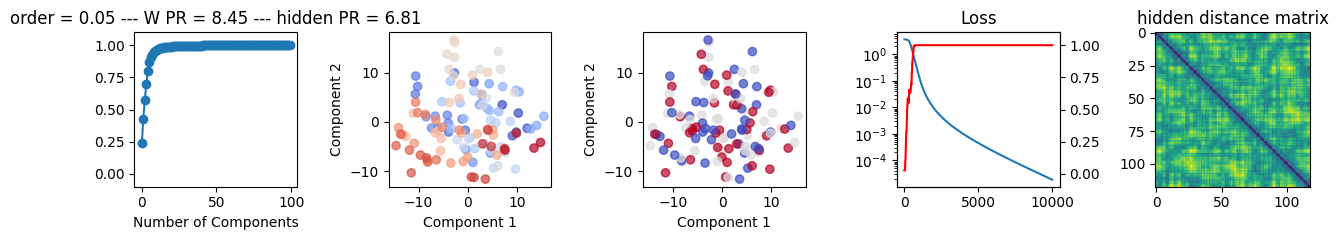

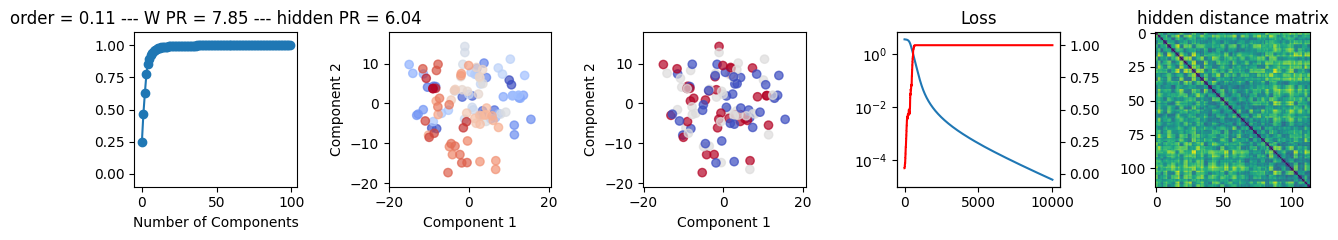

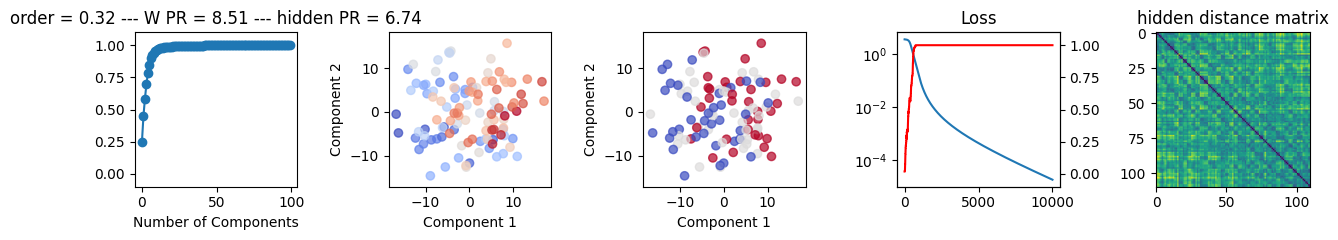

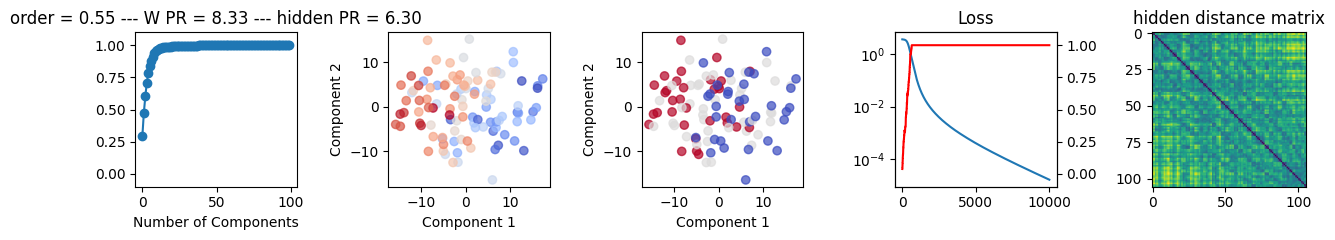

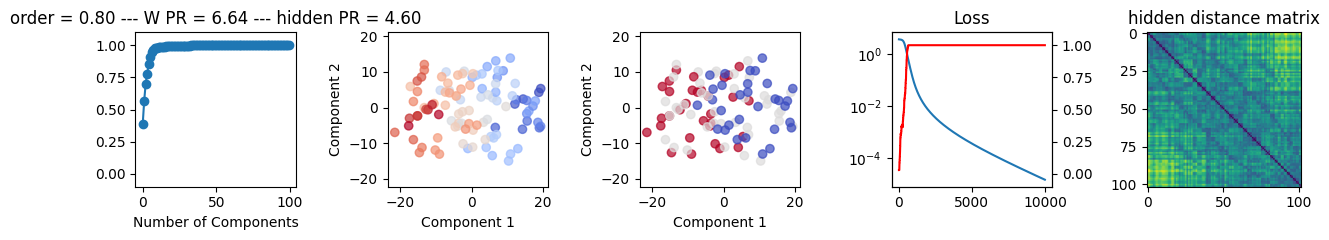

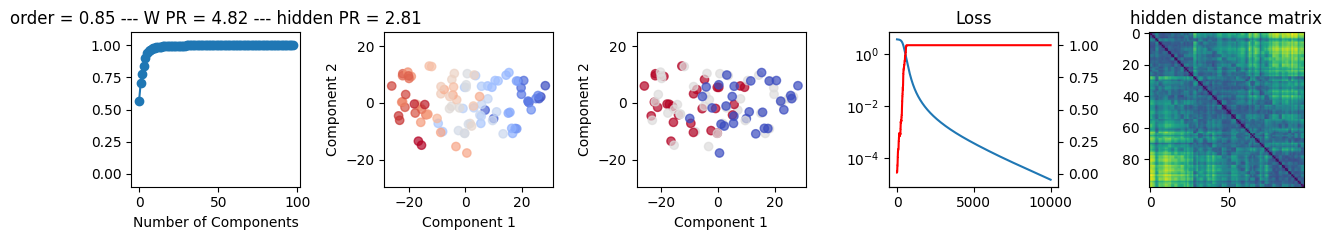

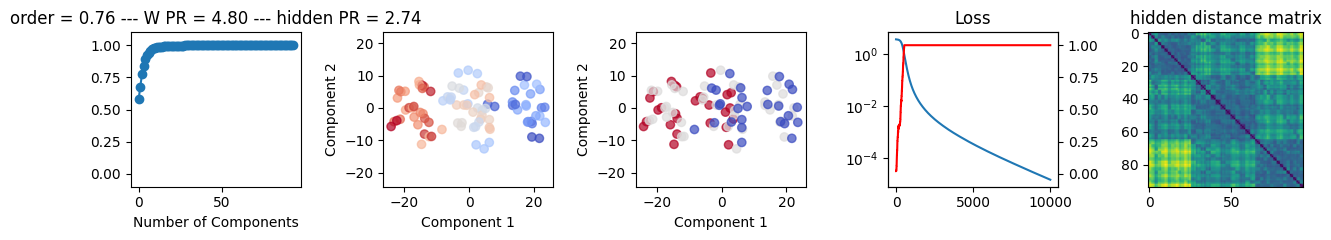

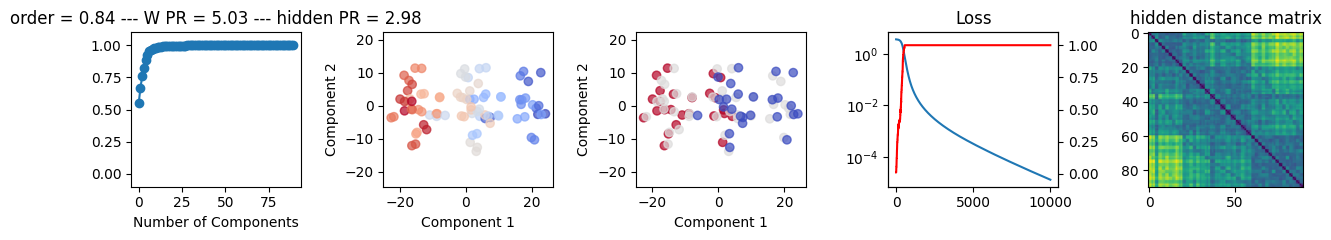

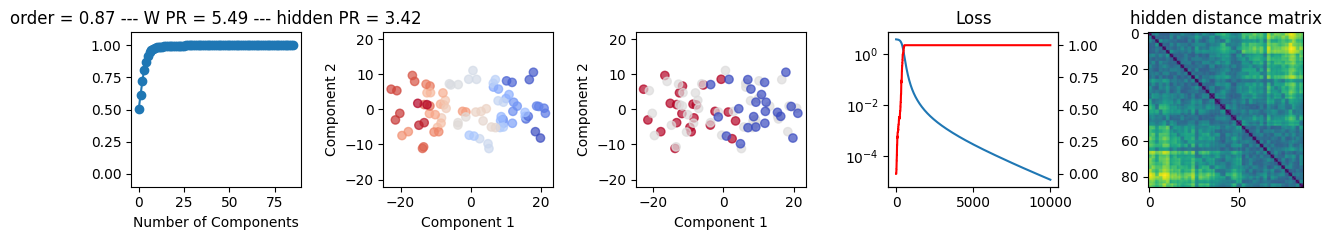

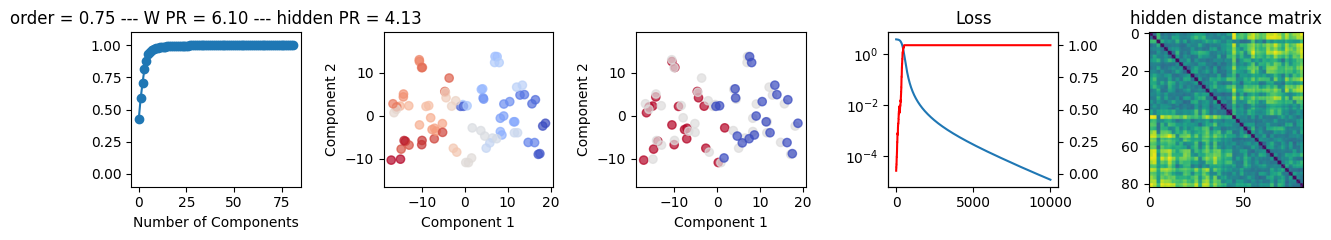

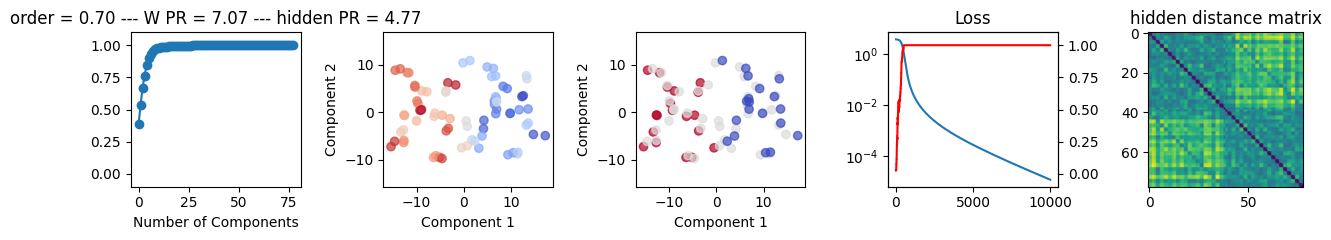

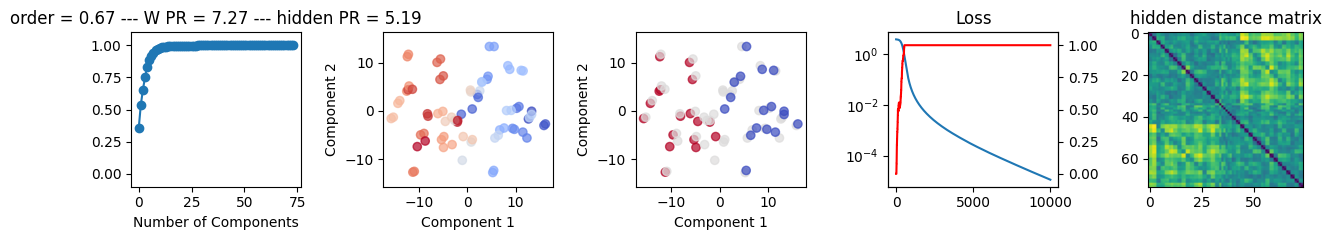

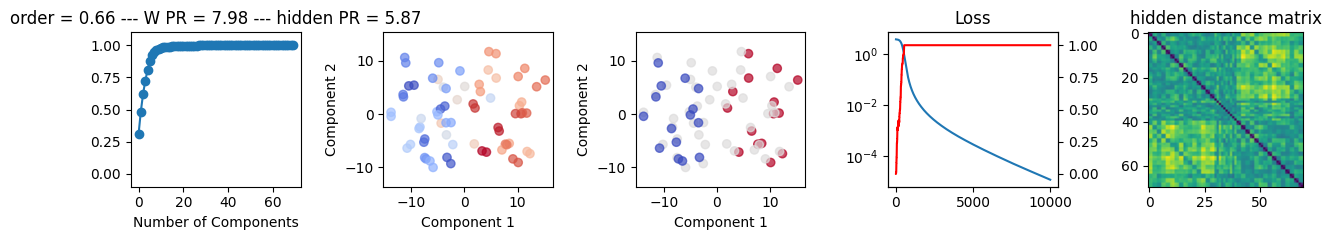

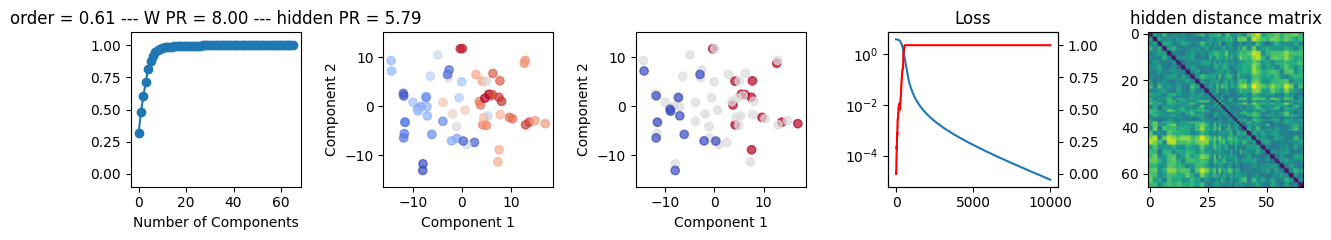

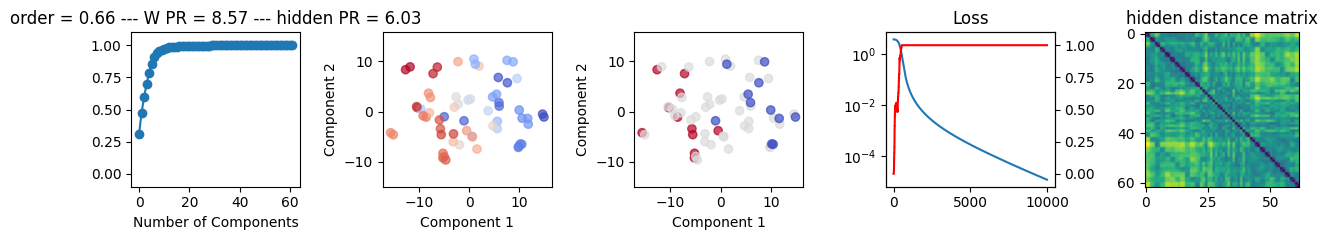

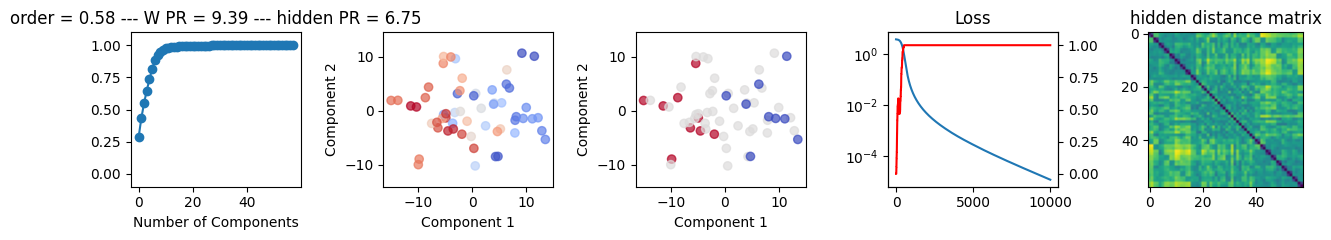

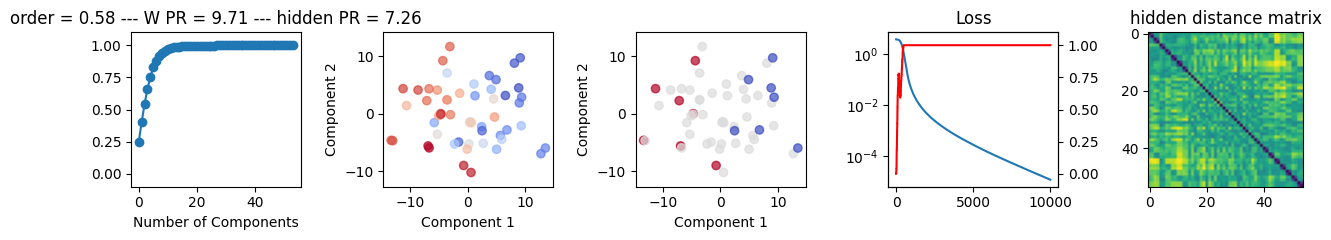

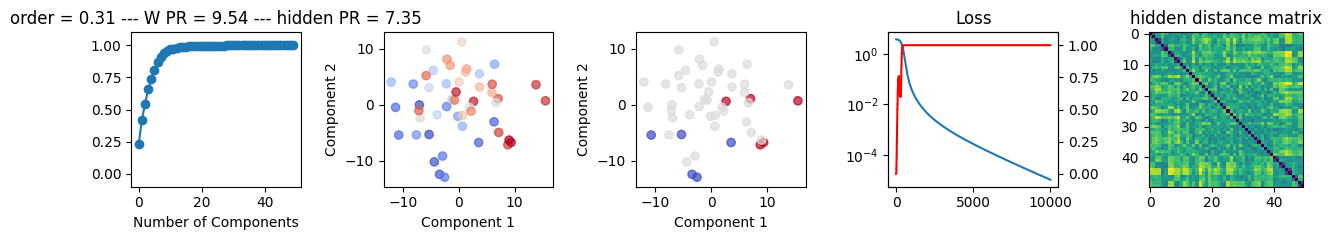

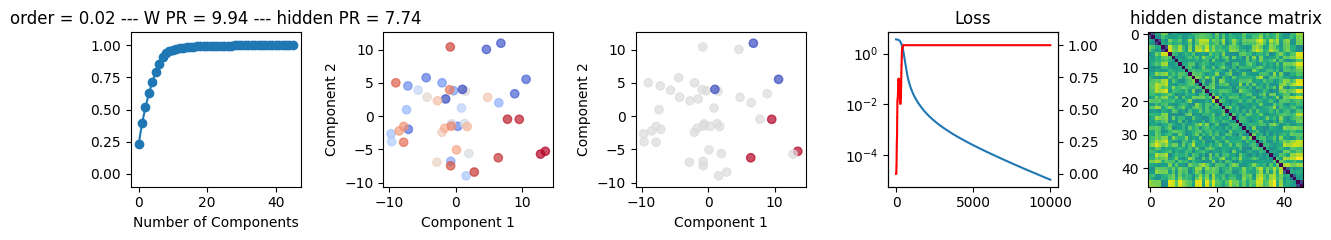

In [32]:
from utils_plot import plot_pca
for data_dict in data_dict_l:
    plot_pca(data_dict, action_filter=100)

In [33]:
def calc_metrics(data_dict, i=-1):
    hidden = data_dict['hidden_states'][i].cpu().detach().numpy()
    PR = calc_PR(hidden)
    loc_y = data_dict['loc_y']
    corridor = data_dict['corridor']
    order = get_r_2(PCA(n_components=1).fit_transform(hidden), loc_y)
    return PR, order

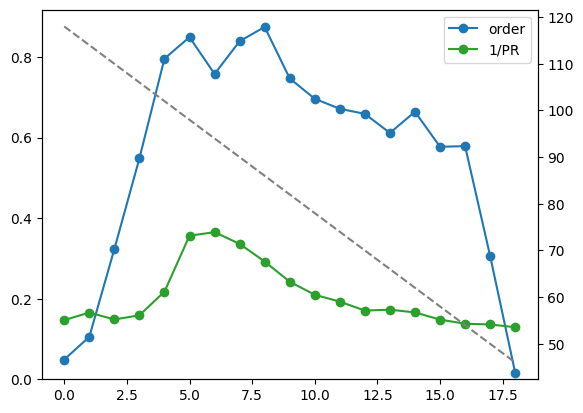

In [34]:
PR_l = []
order_l = []
n_samples_l = []
for data_dict in data_dict_l:
    PR, order = calc_metrics(data_dict)
    PR_l.append(1/PR)
    order_l.append(order)
    n_samples_l.append(data_dict['X'].shape[0])
plt.plot(order_l, label='order', marker='o')   
plt.plot(PR_l, label='1/PR', marker='o', c='tab:green')
plt.legend()
plt.ylim(0)
plt.axhline(1, color='gray', linestyle='--', alpha=0.5)
plt.gca().twinx().plot(n_samples_l, ls='--', c='gray')
plt.show()

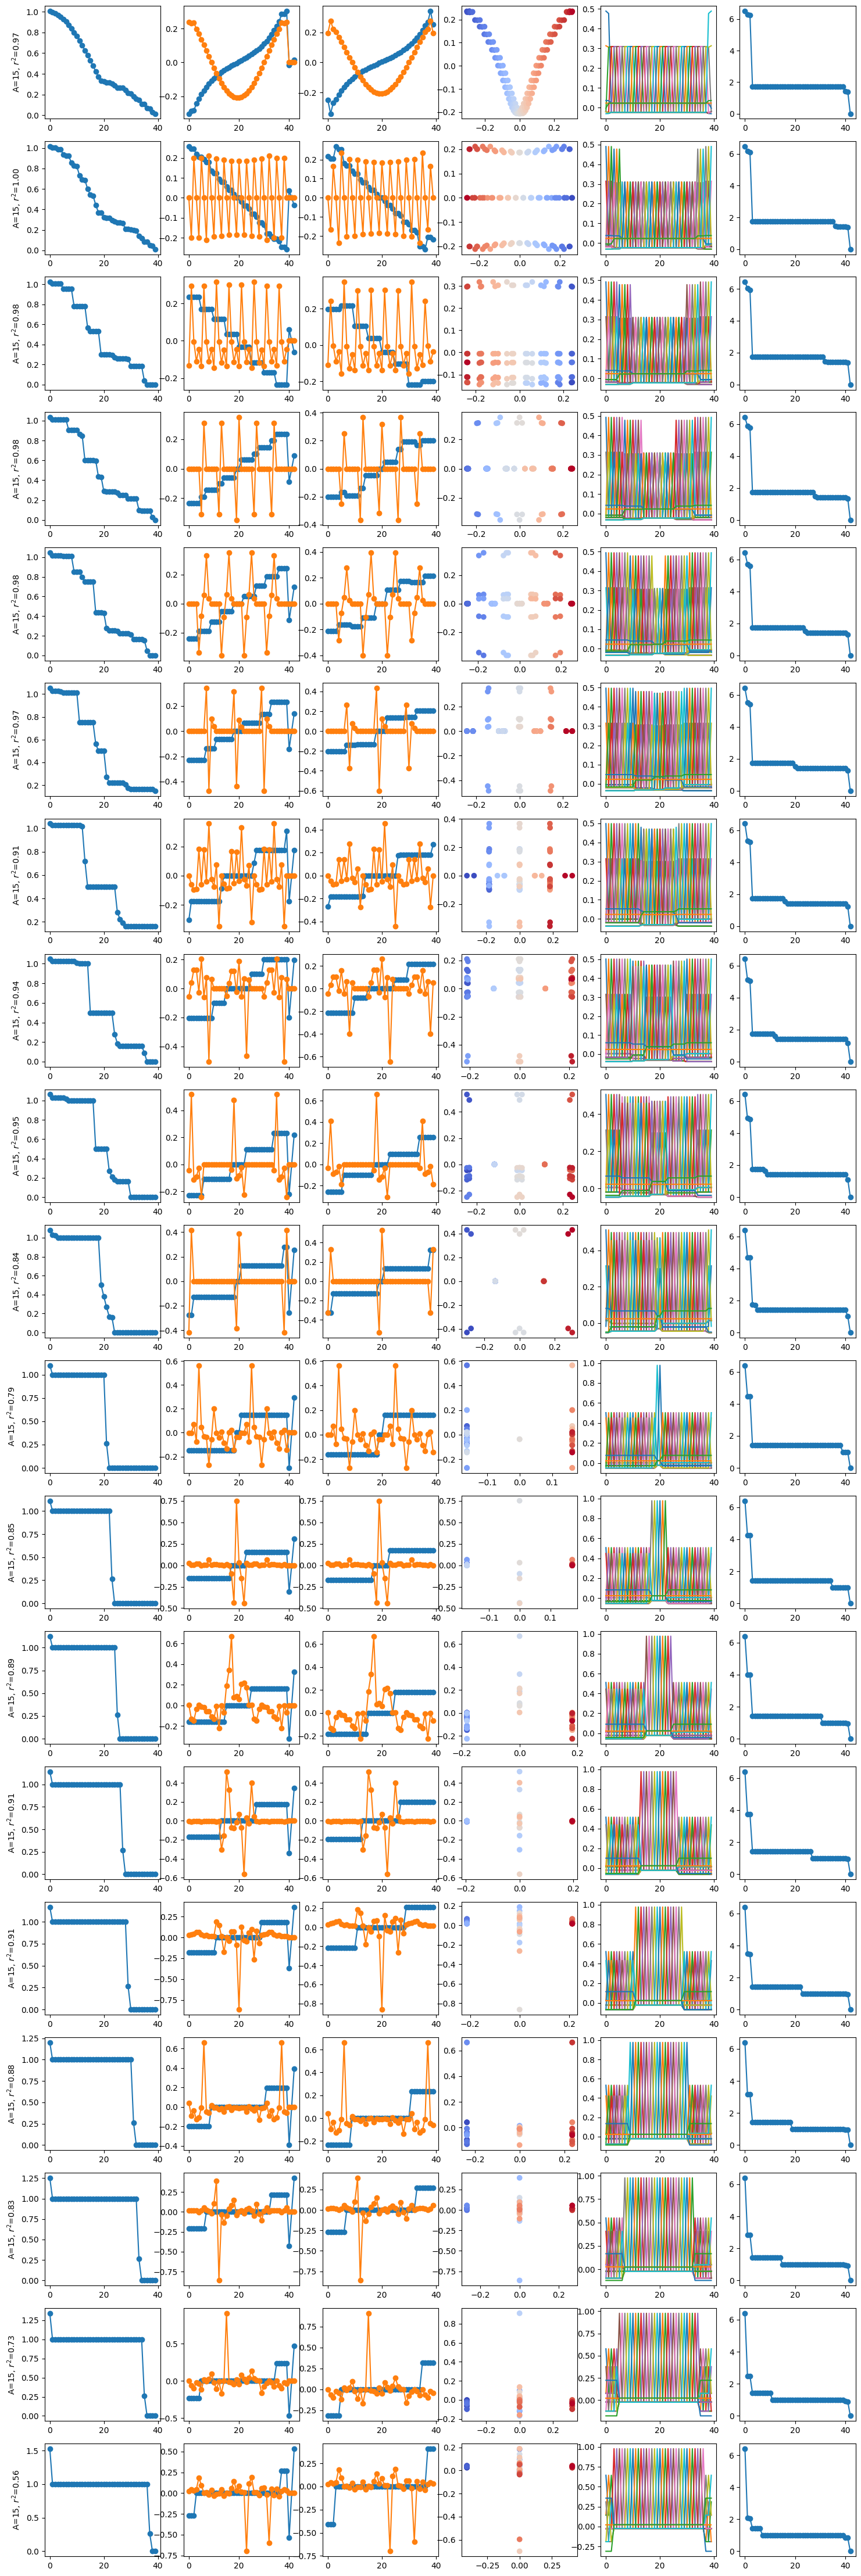

In [35]:
fig, axs_all = plt.subplots(len(data_dict_l),6,figsize=(3*6,3*len(data_dict_l)))
for i, data_dict in enumerate(data_dict_l):
    axs = axs_all[i]
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()
    loc_X = data_dict['loc_X']
    loc_y = data_dict['loc_y']
    action_taken = data_dict['action_taken']
    C = data_dict['C']
    length = C.length_corridors[0]
    A = C.max_move
    X_p = (np.linalg.pinv(X.T @ X) @ X.T)
    Ux, Sx, Vx = np.linalg.svd(X)
    X_p2 = Ux[:,[-1]] @ Vx[[-1],:]
    vx = Vx[[-1], :].T 
    OLS = np.linalg.pinv(X.T @ X) @ X.T @ y
    U, S, V = np.linalg.svd(OLS, full_matrices=False)
    hidden = X@U@np.diag(S)
    r2 = get_r_2(hidden[abs(action_taken)<=100,:1], loc_y[abs(action_taken)<=100])
    axs[0].plot(S, marker = 'o')
    axs[0].set_ylabel(f'A={A}, $r^2$={r2:.2f}')
    for i in range(2):
        axs[1].plot(U[:,i], marker = 'o')
        axs[2].plot(V[i,:], marker = 'o')
    axs[3].scatter(X@U[:,0]*S[0], X@U[:,1]*S[1], c=loc_y, cmap='coolwarm')
    axs[4].plot(OLS.T)
    axs[5].plot(Sx, marker='o')
